## Task #10. Hydrogenic orbitals

Plot 2D slices and 3D visualizations of the probability density |ψ|² for an electron in a hydrogenic atom, given *n*, *l*, *m* quantum numbers. Use the provided solutions to the Schrödinger Equation as a recipe (i.e. no need to derive).

In [2]:
import matplotlib.pyplot as plt
import numpy

<>:167: SyntaxWarning: invalid escape sequence '\A'
<>:168: SyntaxWarning: invalid escape sequence '\A'
<>:172: SyntaxWarning: invalid escape sequence '\A'
<>:173: SyntaxWarning: invalid escape sequence '\A'
<>:177: SyntaxWarning: invalid escape sequence '\A'
<>:178: SyntaxWarning: invalid escape sequence '\A'
<>:187: SyntaxWarning: invalid escape sequence '\s'
<>:167: SyntaxWarning: invalid escape sequence '\A'
<>:168: SyntaxWarning: invalid escape sequence '\A'
<>:172: SyntaxWarning: invalid escape sequence '\A'
<>:173: SyntaxWarning: invalid escape sequence '\A'
<>:177: SyntaxWarning: invalid escape sequence '\A'
<>:178: SyntaxWarning: invalid escape sequence '\A'
<>:187: SyntaxWarning: invalid escape sequence '\s'
/var/folders/v7/wyjt1s6921d86yh5mpfdbq2h0000gp/T/ipykernel_19605/2944633812.py:167: SyntaxWarning: invalid escape sequence '\A'
  axes[0].set_xlabel('X Axis ($\AA$)')
/var/folders/v7/wyjt1s6921d86yh5mpfdbq2h0000gp/T/ipykernel_19605/2944633812.py:168: SyntaxWarning: invali

Generating plane arrays...
Rendering 3-plane visualization panels...
Success! Plot saved as 'hydrogen_orbital_n3_l2_m0_fixed.png'


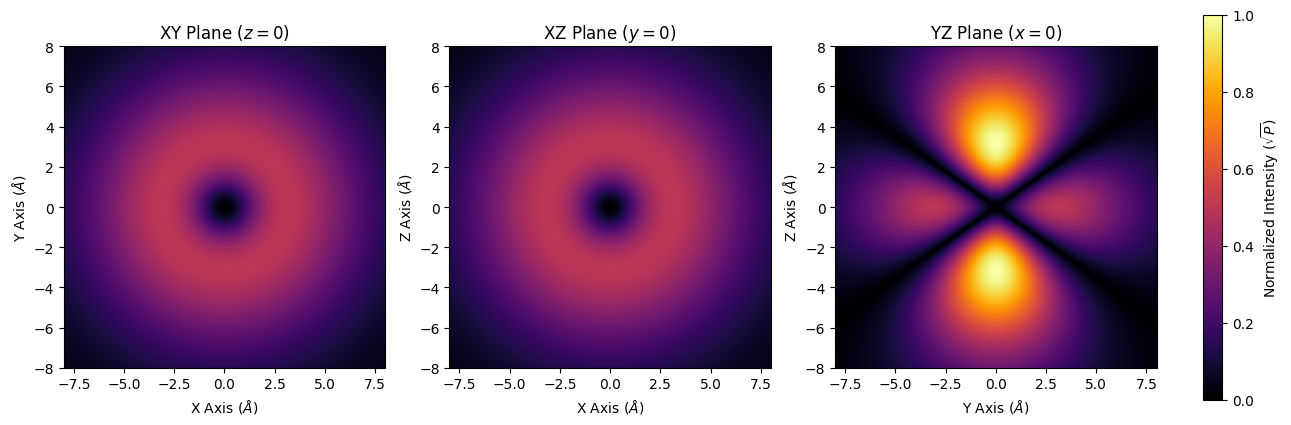

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Global physical constants
h = 6.626 * 10**-34  # Planck's constant
c = 299792458  # Speed of light
e = 1.602176634 * 10**-19  # Elementary Charge of an Electron
me = 9.1093837 * 10**-31  # Electron mass
ep0 = 8.854187817 * 10**-12  # Epsilon 0

# Derived Bohr radius
bohr = (ep0 * (h**2)) / (np.pi * me * (e**2))
hyrad = bohr


def Factorial(n):
    if n <= 0:
        return 1
    val = 1
    for x in range(n):
        val *= x + 1
    return val


def Largrange(x, l, n):
    total = np.zeros_like(x, dtype=float) if isinstance(x, np.ndarray) else 0.0
    for k in range(n - l):
        num = Factorial(l + n) * (-x) ** k
        dem = Factorial(2 * l + 1 + k) * Factorial(n - l - 1 - k) * Factorial(k)
        if dem == 0:
            continue
        total += num / dem
    return total


def Rcalc(n, l, r_val):
    rho = (2 * r_val) / (hyrad * n)
    numSqrt = Factorial(n - l - 1)
    demSqrt = 2 * n * Factorial(n + l)
    sqrtValue = np.sqrt(numSqrt / demSqrt)

    FirstThird = sqrtValue * ((2 / (hyrad * n)) ** (1.5))
    SecondThird = (rho**l) * np.exp(-rho / 2)
    ThirdThird = Largrange(rho, l, n)
    return FirstThird * SecondThird * ThirdThird


def AssociatedLegendreP(x, l, m):
    m_abs = abs(m)
    total = np.zeros_like(x, dtype=float) if isinstance(x, np.ndarray) else 0.0
    for k in range(m_abs, l + 1):
        if (2 * k - l - m_abs) < 0:
            continue
        num = Factorial(2 * k) * (x ** (2 * k - l - m_abs))
        dem = Factorial(k) * Factorial(l - k) * Factorial(2 * k - l - m_abs)
        total += ((-1) ** (l - k)) * (num / dem)

    Plm = ((-1) ** m_abs) * ((1 - x**2) ** (m_abs / 2)) / (2**l) * total
    if m < 0:
        Plm *= ((-1) ** m_abs) * (Factorial(l - m_abs) / Factorial(l + m_abs))
    return Plm


def OmegaCalc(theta, phi, l, m):
    """
    Computes Real Spherical Harmonics directly to completely bypass
    floating-point complex cancellation errors.
    """
    m_abs = abs(m)

    # 1. Compute standard normalization factor for |m|
    FirstSecond = (2 * l + 1) / (4 * np.pi)
    SecondSecond = Factorial(l - m_abs) / Factorial(l + m_abs)
    N = np.sqrt(FirstSecond * SecondSecond)

    # 2. Get the Associated Legendre Polynomial using the positive magnitude
    P = AssociatedLegendreP(np.cos(theta), l, m_abs)

    # 3. Direct real-valued assignment based on quantum state mapping
    if m < 0:
        # Negative m maps directly to the sine component
        return np.sqrt(2) * N * P * np.sin(m_abs * phi)
    elif m == 0:
        # m = 0 remains unchanged
        return N * P
    else:
        # Positive m maps directly to the cosine component
        return np.sqrt(2) * N * P * np.cos(m_abs * phi)


def compute_mesh_slice(X, Y, Z, n, l, m):
    """Helper tool to calculate wavefunction parameters across a grid space."""
    r = np.sqrt(X**2 + Y**2 + Z**2)
    r_safe = np.where(r == 0, 1e-20, r)

    theta = np.arccos(Z / r_safe)
    phi = np.arctan2(Y, X)

    Psi = Rcalc(n, l, r) * OmegaCalc(theta, phi, l, m)
    Prob = Psi**2
    return Psi, Prob


def generate_all_planes(n, l, m, grid_size=200, max_range=20 * hyrad):
    """
    Loops through all 3 primary planes intersecting at the origin (0,0,0).
    Returns coordinates and probability fields for XY, XZ, and YZ slices.
    """
    axis = np.linspace(-max_range, max_range, grid_size)

    # 1. Loop through XY Plane (Z = 0)
    X_xy, Y_xy = np.meshgrid(axis, axis, indexing="ij")
    Z_xy = np.zeros_like(X_xy)
    Psi_xy, Prob_xy = compute_mesh_slice(X_xy, Y_xy, Z_xy, n, l, m)

    # 2. Loop through XZ Plane (Y = 0)
    X_xz, Z_xz = np.meshgrid(axis, axis, indexing="ij")
    Y_xz = np.zeros_like(X_xz)
    Psi_xz, Prob_xz = compute_mesh_slice(X_xz, Z_xz, Y_xz, n, l, m)

    # 3. Loop through YZ Plane (X = 0)
    Y_yz, Z_yz = np.meshgrid(axis, axis, indexing="ij")
    X_yz = np.zeros_like(Y_yz)
    Psi_yz, Prob_yz = compute_mesh_slice(X_yz, Y_yz, Z_yz, n, l, m)

    # Pack up the updated data structures
    coordinates = {
        "xy": (X_xy, Y_xy, Z_xy),
        "xz": (X_xz, Z_xz, Y_xz),
        "yz": (X_yz, Y_yz, Z_yz),
        "max_range": max_range,  # Save max range for spatial plotting bounds
    }

    wavefunctions = {"xy": Psi_xy, "xz": Psi_xz, "yz": Psi_yz}
    probabilities = {"xy": Prob_xy, "xz": Prob_xz, "yz": Prob_yz}

    return coordinates, wavefunctions, probabilities


# ==========================================
# --- INITIALIZE VARIABLES & RUN COMPUTATION ---
# ==========================================

# Active State Setup: Let's view the iconic 3dz^2 orbital (Dumbbell + Donut)
TEST_N = 3
TEST_L = 2
TEST_M = 0

print("Generating plane arrays...")
coords, psis, weights = generate_all_planes(
    n=TEST_N, l=TEST_L, m=TEST_M, grid_size=250, max_range=18 * hyrad
)


# ==========================================
# --- PLOTTING CODE WITH EXPLICIT RANGE BINDING ---
# ==========================================
print("Rendering 3-plane visualization panels...")

global_max = max(weights["xy"].max(), weights["xz"].max(), weights["yz"].max())
if global_max == 0:
    global_max = 1e-20

# Square root scaling to enhance low-intensity boundaries
img_xy = np.sqrt(weights["xy"] / global_max)
img_xz = np.sqrt(weights["xz"] / global_max)
img_yz = np.sqrt(weights["yz"] / global_max)

# CRITICAL FIX: Safe extraction of spatial range boundaries using saved scalar limit
max_r = coords["max_range"]
extent_m = [-max_r, max_r, -max_r, max_r]
extent_A = [val * 1e10 for val in extent_m]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cmap = plt.cm.inferno

# Plot each plane using correct subplot list indexing
im0 = axes[0].imshow(
    img_xy.T, extent=extent_A, origin="lower", cmap=cmap, vmin=0, vmax=1
)
axes[0].set_title(f"XY Plane ($z=0$)")
axes[0].set_xlabel("X Axis ($\AA$)")
axes[0].set_ylabel("Y Axis ($\AA$)")

im1 = axes[1].imshow(
    img_xz.T, extent=extent_A, origin="lower", cmap=cmap, vmin=0, vmax=1
)
axes[1].set_title(f"XZ Plane ($y=0$)")
axes[1].set_xlabel("X Axis ($\AA$)")
axes[1].set_ylabel("Z Axis ($\AA$)")

im2 = axes[2].imshow(
    img_yz.T, extent=extent_A, origin="lower", cmap=cmap, vmin=0, vmax=1
)
axes[2].set_title(f"YZ Plane ($x=0$)")
axes[2].set_xlabel("Y Axis ($\AA$)")
axes[2].set_ylabel("Z Axis ($\AA$)")

# Zoom limits and grid removal
for ax in axes:
    ax.grid(False)
    ax.set_xlim(-8, 8)
    ax.set_ylim(-8, 8)

# Connect colorbar safely to our shared intensity range
fig.colorbar(
    im0,
    ax=axes.tolist(),
    label="Normalized Intensity ($\sqrt{P}$)",
    fraction=0.02,
    pad=0.04,
)

output_filename = f"hydrogen_orbital_n{TEST_N}_l{TEST_L}_m{TEST_M}_fixed.png"
plt.savefig(output_filename, dpi=300, bbox_inches="tight")
print(f"Success! Plot saved as '{output_filename}'")
plt.show()